In [12]:
!pip install matplotlib
!pip install seaborn
!pip install GPUtil

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for GPUtil: filename=gputil-1.4.0-py3-none-any.whl size=7437 sha256=de363a650c70f6c1203058a03ceae43fff10bd416f5c48b4eb60f4da8cd4b4b3
  Stored in directory: /Users/sunjae/Library/Caches/pip/wheels/2b/b5/24/fbb56595c286984f7315ee31821d6121e1b9828436021a88b3
Successfully built GPUtil


In [1]:
import sys
print(sys.executable)

/Users/sunjae/miniforge3/envs/annotated-transformer/bin/python


In [61]:
import torch
import torchtext
import spacy

print(torch.__version__)
print(torchtext.__version__)
print(spacy.__version__)

1.11.0
0.12.0
3.5.4


In [13]:
import os
import math
import copy
import time
from os.path import exists

import torch
import torch.nn as nn
from torch.nn.functional import log_softmax, pad
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import altair as alt

from torchtext.data.functional import to_map_style_dataset
from torch.utils.data import DataLoader

from torchtext.vocab import build_vocab_from_iterator
import torchtext.datasets as datasets
import spacy

import GPUtil
import warnings
from torch.utils.data.distributed import DistributedSampler
import torch.distributed as dist
import torch.multiprocessing as mp
from torch.nn.parallel import DistributedDataParallel as DDP

In [14]:
warnings.filterwarnings("ignore")

RUN_EXAMPLES = True

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


# 모델 구현

In [16]:
def clones(module, N):
    "Produce N identical layers."
    return nn.ModuleList([copy.deepcopy(module) for _ in range(N)])

In [19]:
class EncoderDecoder(nn.Module):
    """
    기본 인코더-디코더 구조. 
    많은 모델의 base가 된다!
    """

    def __init__(self, encoder, decoder, src_embed, tgt_embed, generator):
        super(EncoderDecoder, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_embed = src_embed
        self.tgt_embed = tgt_embed
        self.generator = generator

    def forward(self, src, tgt, src_mask, tgt_mask):
        return self.decode(self.encode(src, src_mask), src_mask, tgt, tgt_mask)

    def encode(self, src, src_mask):
        return self.encoder(self.src_embed(src), src_mask)

    def decode(self, memory, src_mask, tgt, tgt_mask):
        return self.decoder(self.tgt_embed(tgt), memory, src_mask, tgt_mask)

class Generator(nn.Module):
    "standard linear + softmax generation."

    def __init__(self, d_model, vocab):
        super(Generator, self).__init__()
        self.proj = nn.Linear(d_model, vocab)

    def forward(self, x):
        return log_softmax(self.proj(x), dim = -1)

In [21]:
class LayerNorm(nn.Module):
    "Construct a layernorm module."

    def __init__(self, features, eps=1e-6):
        super(LayerNorm, self).__init__()
        self.a_2 = nn.Parameter(torch.ones(features))
        self.b_2 = nn.Parameter(torch.zeros(features))
        self.eps = eps

    def forward(self, x):
        mean = x.mean(-1, keepdim=True)
        std = x.std(-1, keepdim=True)
        return self.a_2 * (x - mean) / (std + self.eps) + self.b_2


class SublayerConnection(nn.Module):
    """
    A residual connection followed by a layer norm.
    Note for code simplicity the norm is first as opposed to last.
    """

    def __init__(self, size, dropout):
        super(SublayerConnection, self).__init__()
        self.norm = LayerNorm(size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, sublayer):
        return x + self.dropout(sublayer(self.norm(x)))

In [22]:
class Encoder(nn.Module):
    "Core encoder is a stack of N layers"

    def __init__(self, layer, N):
        super(Encoder, self).__init__()
        self.layers = clones(layer, N)
        self.norm = LayerNorm(layer.size)

    def forward(self, x, mask):
        "Pass the input (and mask) through each layer in turn."
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)


class EncoderLayer(nn.Module):
    "Encoder is made up of self-attn and feed forward"

    def __init__(self, size, self_attn, feed_forward, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = self_attn
        self.feed_forward = feed_forward
        self.sublayer = clones(SublayerConnection(size, dropout), 2)
        self.size = size

    def forward(self, x, mask):
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, mask))
        return self.sublayer[1](x, self.feed_forward)

In [23]:
class Decoder(nn.Module):
    "Generic N layer decoder with masking."

    def __init__(self, layer, N):
        super(Decoder, self).__init__()
        self.layers = clones(layer, N)
        self.norm = LayerNorm(layer.size)

    def forward(self, x, memory, src_mask, tgt_mask):
        for layer in self.layers:
            x = layer(x, memory, src_mask, tgt_mask)
        return self.norm(x)


class DecoderLayer(nn.Module):
    "Decoder is made of self-attn, src-attn, and feed forward"

    def __init__(self, size, self_attn, src_attn, feed_forward, dropout):
        super(DecoderLayer, self).__init__()
        self.size = size
        self.self_attn = self_attn
        self.src_attn = src_attn
        self.feed_forward = feed_forward
        self.sublayer = clones(SublayerConnection(size, dropout), 3)

    def forward(self, x, memory, src_mask, tgt_mask):
        m = memory
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, tgt_mask))
        x = self.sublayer[1](x, lambda x: self.src_attn(x, m, m, src_mask))
        return self.sublayer[2](x, self.feed_forward)

# Mask와 Attention 구현

In [24]:
def subsequent_mask(size):
    "Mask out subsequent positions."
    attn_shape = (1, size, size)
    subsequent_mask = torch.triu(torch.ones(attn_shape), diagonal=1).type(torch.uint8)
    return subsequent_mask == 0

## mask 시각화

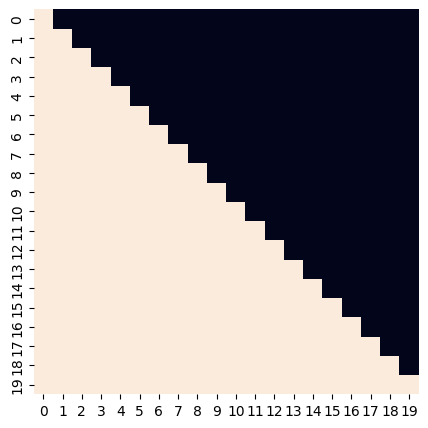

In [26]:
plt.figure(figsize=(5, 5))
sns.heatmap(subsequent_mask(20)[0].int(), square=True, cbar=False)
plt.show()

In [27]:
def attention(query, key, value, mask=None, dropout=None):
    "Compute 'Scaled Dot Product Attention'"
    d_k = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)

    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)

    p_attn = scores.softmax(dim=-1)

    if dropout is not None:
        p_attn = dropout(p_attn)

    return torch.matmul(p_attn, value), p_attn

In [28]:
class MultiHeadedAttention(nn.Module):
    def __init__(self, h, d_model, dropout=0.1):
        "Take in model size and number of heads."
        super(MultiHeadedAttention, self).__init__()
        assert d_model % h == 0

        self.d_k = d_model // h
        self.h = h
        self.linears = clones(nn.Linear(d_model, d_model), 4)
        self.attn = None
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):
        if mask is not None:
            mask = mask.unsqueeze(1)

        nbatches = query.size(0)

        query, key, value = [
            lin(x).view(nbatches, -1, self.h, self.d_k).transpose(1, 2)
            for lin, x in zip(self.linears, (query, key, value))
        ]

        x, self.attn = attention(query, key, value, mask=mask, dropout=self.dropout)

        x = (
            x.transpose(1, 2)
            .contiguous()
            .view(nbatches, -1, self.h * self.d_k)
        )

        del query
        del key
        del value

        return self.linears[-1](x)

In [29]:
temp_mha = MultiHeadedAttention(h=8, d_model=512)
x = torch.randn(2, 10, 512)
mask = subsequent_mask(10)

out = temp_mha(x, x, x, mask)
print(out.shape)

torch.Size([2, 10, 512])


# FeedForwardNetwork, Positional Encoding, Model

In [30]:
class PositionwiseFeedForward(nn.Module):
    "Implements FFN equation."

    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.w_2(self.dropout(self.w_1(x).relu()))

In [31]:
class Embeddings(nn.Module):
    def __init__(self, d_model, vocab):
        super(Embeddings, self).__init__()
        self.lut = nn.Embedding(vocab, d_model)
        self.d_model = d_model

    def forward(self, x):
        return self.lut(x) * math.sqrt(self.d_model)

In [32]:
class PositionalEncoding(nn.Module):
    "Implement the PE function."

    def __init__(self, d_model, dropout, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[:, : x.size(1)].requires_grad_(False)
        return self.dropout(x)

## positional encoding 시각화

In [46]:
def example_positional():
    pe = PositionalEncoding(20, 0)
    y = pe.forward(torch.zeros(1, 100, 20))

    data = pd.concat(
        [
            pd.DataFrame(
                {
                    "embedding": y[0, :, dim],
                    "dimension": dim,
                    "position": list(range(100)),
                }
            )
            for dim in [4, 5, 6, 7]
        ]
    )

    return (
        alt.Chart(data)
        .mark_line()
        .properties(width=800)
        .encode(x="position", y="embedding", color="dimension:N")
        .interactive()
    )
def show_example(fn, args=[]):
    if __name__ == "__main__" and RUN_EXAMPLES:
        return fn(*args)

show_example(example_positional)

alt.Chart(...)

In [34]:
def make_model(
    src_vocab,
    tgt_vocab,
    N=6,
    d_model=512,
    d_ff=2048,
    h=8,
    dropout=0.1,
):
    "Helper: Construct a model from hyperparameters."
    c = copy.deepcopy
    attn = MultiHeadedAttention(h, d_model)
    ff = PositionwiseFeedForward(d_model, d_ff, dropout)
    position = PositionalEncoding(d_model, dropout)

    model = EncoderDecoder(
        Encoder(EncoderLayer(d_model, c(attn), c(ff), dropout), N),
        Decoder(DecoderLayer(d_model, c(attn), c(attn), c(ff), dropout), N),
        nn.Sequential(Embeddings(d_model, src_vocab), c(position)),
        nn.Sequential(Embeddings(d_model, tgt_vocab), c(position)),
        Generator(d_model, tgt_vocab),
    )

    for p in model.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)

    return model

In [36]:
tmp_model = make_model(11, 11, N=2)
print(tmp_model)

EncoderDecoder(
  (encoder): Encoder(
    (layers): ModuleList(
      (0): EncoderLayer(
        (self_attn): MultiHeadedAttention(
          (linears): ModuleList(
            (0): Linear(in_features=512, out_features=512, bias=True)
            (1): Linear(in_features=512, out_features=512, bias=True)
            (2): Linear(in_features=512, out_features=512, bias=True)
            (3): Linear(in_features=512, out_features=512, bias=True)
          )
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (feed_forward): PositionwiseFeedForward(
          (w_1): Linear(in_features=512, out_features=2048, bias=True)
          (w_2): Linear(in_features=2048, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sublayer): ModuleList(
          (0): SublayerConnection(
            (norm): LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): SublayerConnection(
            (norm): LayerNorm()

In [37]:
src = torch.LongTensor([[1, 2, 3, 4, 5]])
tgt = torch.LongTensor([[1, 2, 3, 4]])

src_mask = torch.ones(1, 1, 5)
tgt_mask = subsequent_mask(4)

out = tmp_model(src, tgt, src_mask, tgt_mask)
print(out.shape)

torch.Size([1, 4, 512])


# Utility for Training

In [38]:
class Batch:
    """Object for holding a batch of data with mask during training."""

    def __init__(self, src, tgt=None, pad=2):  # 2 = <blank>
        self.src = src
        self.src_mask = (src != pad).unsqueeze(-2)

        if tgt is not None:
            self.tgt = tgt[:, :-1]
            self.tgt_y = tgt[:, 1:]
            self.tgt_mask = self.make_std_mask(self.tgt, pad)
            self.ntokens = (self.tgt_y != pad).data.sum()

    @staticmethod
    def make_std_mask(tgt, pad):
        "Create a mask to hide padding and future words."
        tgt_mask = (tgt != pad).unsqueeze(-2)
        tgt_mask = tgt_mask & subsequent_mask(tgt.size(-1)).type_as(tgt_mask.data)
        return tgt_mask

In [39]:
class TrainState:
    """Track number of steps, examples, and tokens processed"""

    step: int = 0
    accum_step: int = 0
    samples: int = 0
    tokens: int = 0

In [40]:
def run_epoch(
    data_iter,
    model,
    loss_compute,
    optimizer,
    scheduler,
    mode="train",
    accum_iter=1,
    train_state=TrainState(),
):
    """Train a single epoch"""
    start = time.time()
    total_tokens = 0
    total_loss = 0
    tokens = 0

    n_accum = 0
    for i, batch in enumerate(data_iter):
        out = model.forward(
            batch.src, batch.tgt, batch.src_mask, batch.tgt_mask
        )
        loss, loss_node = loss_compute(out, batch.tgt_y, batch.ntokens)

        if mode in ["train", "train+log"]:
            loss_node.backward()
            train_state.step += 1
            train_state.samples += batch.src.shape[0]
            train_state.tokens += batch.ntokens

            if i % accum_iter == 0:
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)
                n_accum += 1
                train_state.accum_step += 1

            scheduler.step()

        total_loss += loss
        total_tokens += batch.ntokens
        tokens += batch.ntokens

        if i % 40 == 1 and (mode == "train" or mode == "train+log"):
            lr = optimizer.param_groups[0]["lr"]
            elapsed = time.time() - start
            print(
                (
                    "Epoch Step: %6d | Accumulation Step: %3d | Loss: %6.2f "
                    + "| Tokens / Sec: %7.1f | Learning Rate: %6.1e"
                )
                % (i, n_accum, loss / batch.ntokens, tokens / elapsed, lr)
            )
            start = time.time()
            tokens = 0

        del loss
        del loss_node

    return total_loss / total_tokens, train_state

In [41]:
def rate(step, model_size, factor, warmup):
    """
    we have to default the step to 1 for LambdaLR function
    to avoid zero raising to negative power.
    """
    if step == 0:
        step = 1
    return factor * (
        model_size ** (-0.5) * min(step ** (-0.5), step * warmup ** (-1.5))
    )

In [42]:
class LabelSmoothing(nn.Module):
    "Implement label smoothing."

    def __init__(self, size, padding_idx, smoothing=0.0):
        super(LabelSmoothing, self).__init__()
        self.criterion = nn.KLDivLoss(reduction="sum")
        self.padding_idx = padding_idx
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.size = size
        self.true_dist = None

    def forward(self, x, target):
        assert x.size(1) == self.size
        true_dist = x.data.clone()
        true_dist.fill_(self.smoothing / (self.size - 2))
        true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
        true_dist[:, self.padding_idx] = 0

        mask = torch.nonzero(target.data == self.padding_idx)
        if mask.dim() > 0:
            true_dist.index_fill_(0, mask.squeeze(), 0.0)

        self.true_dist = true_dist
        return self.criterion(x, true_dist.clone().detach())

In [43]:
def example_label_smoothing():
    crit = LabelSmoothing(size=5, padding_idx=0, smoothing=0.4)
    predict = torch.FloatTensor(
        [
            [0, 0.2, 0.7, 0.1, 0],
            [0, 0.2, 0.7, 0.1, 0],
            [0, 0.2, 0.7, 0.1, 0],
            [0, 0.2, 0.7, 0.1, 0],
            [0, 0.2, 0.7, 0.1, 0],
        ]
    )
    crit(predict.log(), torch.LongTensor([2, 1, 0, 3, 3]))

    return pd.DataFrame(
        {
            "target distribution": crit.true_dist.flatten(),
            "column": [i for i in range(5)] * 5,
            "row": sum([[i] * 5 for i in range(5)], []),
        }
    )

df = example_label_smoothing()

alt.Chart(df).mark_rect().encode(
    x="column:O",
    y="row:O",
    color="target distribution:Q"
).properties(width=300, height=300)

alt.Chart(...)

In [44]:
crit = LabelSmoothing(size=5, padding_idx=0, smoothing=0.1)
predict = torch.tensor([[0.0, 0.2, 0.7, 0.1, 0.0]])
target = torch.tensor([2])

loss = crit(predict.log(), target)
print("loss:", loss.item())
print("true_dist:", crit.true_dist)

loss: inf
true_dist: tensor([[0.0000, 0.0333, 0.9000, 0.0333, 0.0333]])


# Synthetic Data 학습

In [47]:
def data_gen(V, batch_size, nbatches):
    "Generate random data for a src-tgt copy task."
    for i in range(nbatches):
        data = torch.randint(1, V, size=(batch_size, 10))
        data[:, 0] = 1
        src = data.requires_grad_(False).clone().detach()
        tgt = data.requires_grad_(False).clone().detach()
        yield Batch(src, tgt, 0)

In [48]:
class SimpleLossCompute:
    "A simple loss compute and train function."

    def __init__(self, generator, criterion):
        self.generator = generator
        self.criterion = criterion

    def __call__(self, x, y, norm):
        x = self.generator(x)
        sloss = (
            self.criterion(
                x.contiguous().view(-1, x.size(-1)),
                y.contiguous().view(-1),
            )
            / norm
        )
        return sloss.data * norm, sloss

In [49]:
V = 11
criterion = LabelSmoothing(size=V, padding_idx=0, smoothing=0.0)

model = make_model(V, V, N=2, d_model=128, d_ff=512, h=4, dropout=0.1)
model.to(device)

EncoderDecoder(
  (encoder): Encoder(
    (layers): ModuleList(
      (0): EncoderLayer(
        (self_attn): MultiHeadedAttention(
          (linears): ModuleList(
            (0): Linear(in_features=128, out_features=128, bias=True)
            (1): Linear(in_features=128, out_features=128, bias=True)
            (2): Linear(in_features=128, out_features=128, bias=True)
            (3): Linear(in_features=128, out_features=128, bias=True)
          )
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (feed_forward): PositionwiseFeedForward(
          (w_1): Linear(in_features=128, out_features=512, bias=True)
          (w_2): Linear(in_features=512, out_features=128, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sublayer): ModuleList(
          (0): SublayerConnection(
            (norm): LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): SublayerConnection(
            (norm): LayerNorm()
 

In [50]:
optimizer = torch.optim.Adam(
    model.parameters(), lr=0.5, betas=(0.9, 0.98), eps=1e-9
)

scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer=optimizer,
    lr_lambda=lambda step: rate(step, model_size=model.src_embed[0].d_model, factor=1.0, warmup=400)
)

In [52]:
class DummyOptimizer(torch.optim.Optimizer):
    def __init__(self):
        self.param_groups = [{"lr": 0}]
        self.defaults = {}

    def step(self):
        None

    def zero_grad(self, set_to_none=False):
        None


class DummyScheduler:
    def step(self):
        None

In [53]:
for epoch in range(10):
    model.train()
    run_epoch(
        data_gen(V, 80, 20),
        model,
        SimpleLossCompute(model.generator, criterion),
        optimizer,
        scheduler,
        mode="train",
    )

    model.eval()
    loss, _ = run_epoch(
        data_gen(V, 80, 5),
        model,
        SimpleLossCompute(model.generator, criterion),
        DummyOptimizer(),
        DummyScheduler(),
        mode="eval",
    )

    print(f"Epoch {epoch:02d} | validation loss: {loss:.4f}")

Epoch Step:      1 | Accumulation Step:   2 | Loss:   2.59 | Tokens / Sec: 11677.0 | Learning Rate: 1.2e-04
Epoch 00 | validation loss: 2.0134
Epoch Step:      1 | Accumulation Step:   2 | Loss:   2.10 | Tokens / Sec: 18771.7 | Learning Rate: 2.3e-04
Epoch 01 | validation loss: 1.7517
Epoch Step:      1 | Accumulation Step:   2 | Loss:   1.85 | Tokens / Sec: 18533.3 | Learning Rate: 3.4e-04
Epoch 02 | validation loss: 1.5432
Epoch Step:      1 | Accumulation Step:   2 | Loss:   1.68 | Tokens / Sec: 18612.1 | Learning Rate: 4.5e-04
Epoch 03 | validation loss: 1.1833
Epoch Step:      1 | Accumulation Step:   2 | Loss:   1.45 | Tokens / Sec: 18349.3 | Learning Rate: 5.6e-04
Epoch 04 | validation loss: 0.7889
Epoch Step:      1 | Accumulation Step:   2 | Loss:   1.12 | Tokens / Sec: 18278.5 | Learning Rate: 6.7e-04
Epoch 05 | validation loss: 0.4581
Epoch Step:      1 | Accumulation Step:   2 | Loss:   0.91 | Tokens / Sec: 18014.5 | Learning Rate: 7.8e-04
Epoch 06 | validation loss: 0.1996

In [54]:
def greedy_decode(model, src, src_mask, max_len, start_symbol):
    memory = model.encode(src, src_mask)
    ys = torch.zeros(1, 1).fill_(start_symbol).type_as(src.data)

    for i in range(max_len - 1):
        out = model.decode(
            memory,
            src_mask,
            ys,
            subsequent_mask(ys.size(1)).type_as(src.data),
        )
        prob = model.generator(out[:, -1])
        _, next_word = torch.max(prob, dim=1)
        next_word = next_word.data[0]
        ys = torch.cat(
            [ys, torch.zeros(1, 1).type_as(src.data).fill_(next_word)], dim=1
        )

    return ys

In [56]:
model.eval()

src = torch.LongTensor([[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]])
src_mask = torch.ones(1, 1, 10)

result = greedy_decode(model, src, src_mask, max_len=10, start_symbol=1)
print("src   :", src)
print("pred  :", result)

src   : tensor([[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]])
pred  : tensor([[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]])


# Spacy tokenizer 로드

In [57]:
import spacy

spacy_de = spacy.load("de_core_news_sm")
spacy_en = spacy.load("en_core_web_sm")

# tokenizer 함수 정의

In [58]:
def tokenize(text, tokenizer):
    return [tok.text for tok in tokenizer.tokenizer(text)]


def tokenize_de(text):
    return tokenize(text, spacy_de)


def tokenize_en(text):
    return tokenize(text, spacy_en)

In [59]:
# 토크나이저 테스트

print(tokenize_de("Ein Pferd geht unter einer Brücke neben einem Boot."))
print(tokenize_en("A horse walks under a bridge next to a boat."))

['Ein', 'Pferd', 'geht', 'unter', 'einer', 'Brücke', 'neben', 'einem', 'Boot', '.']
['A', 'horse', 'walks', 'under', 'a', 'bridge', 'next', 'to', 'a', 'boat', '.']


In [89]:
# Multi30k import 및 샘플 확인

import os
import gzip
import shutil
import urllib.request

DATA_DIR = ".data/multi30k"
os.makedirs(DATA_DIR, exist_ok=True)

BASE_URL = "https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw/"
FILES = {
    "train.de": "train.de.gz",
    "train.en": "train.en.gz",
    "val.de": "val.de.gz",
    "val.en": "val.en.gz",
    "test.de": "test_2016_flickr.de.gz",
    "test.en": "test_2016_flickr.en.gz",
}

def download_and_extract(base_url, remote_name, local_txt_path):
    gz_path = local_txt_path + ".gz"
    if not os.path.exists(local_txt_path):
        if not os.path.exists(gz_path):
            url = base_url + remote_name
            print(f"Downloading: {url}")
            urllib.request.urlretrieve(url, gz_path)

        print(f"Extracting: {gz_path}")
        with gzip.open(gz_path, "rb") as f_in:
            with open(local_txt_path, "wb") as f_out:
                shutil.copyfileobj(f_in, f_out)

for local_name, remote_name in FILES.items():
    local_path = os.path.join(DATA_DIR, local_name)
    download_and_extract(BASE_URL, remote_name, local_path)

print("Done.")
print(os.listdir(DATA_DIR))

Done.
['train.de', 'train.en.gz', 'test.en.gz', 'val.en.gz', 'val.de.gz', 'test.de.gz', 'train.de.gz', 'train.en', 'val.en', 'test.en', 'test.de', 'val.de']


In [63]:
# 파일 읽기 함수

def read_lines(path):
    with open(path, "r", encoding="utf-8") as f:
        return [line.strip() for line in f]

train_de = read_lines(os.path.join(DATA_DIR, "train.de"))
train_en = read_lines(os.path.join(DATA_DIR, "train.en"))
val_de   = read_lines(os.path.join(DATA_DIR, "val.de"))
val_en   = read_lines(os.path.join(DATA_DIR, "val.en"))
test_de  = read_lines(os.path.join(DATA_DIR, "test.de"))
test_en  = read_lines(os.path.join(DATA_DIR, "test.en"))

print(len(train_de), len(train_en))
print(len(val_de), len(val_en))
print(len(test_de), len(test_en))

print()
print("DE:", train_de[0])
print("EN:", train_en[0])

29000 29000
1014 1014
1000 1000

DE: Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.
EN: Two young, White males are outside near many bushes.


In [90]:
# dataset 형태 만들기

train_data = list(zip(train_de, train_en))
valid_data = list(zip(val_de, val_en))
test_data  = list(zip(test_de, test_en))

print(train_data[0])
print(valid_data[0])
print(test_data[0])

('Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.', 'Two young, White males are outside near many bushes.')
('Eine Gruppe von Männern lädt Baumwolle auf einen Lastwagen', 'A group of men are loading cotton onto a truck')
('Ein Mann mit einem orangefarbenen Hut, der etwas anstarrt.', 'A man in an orange hat starring at something.')


In [65]:
def yield_tokens(data_iter, tokenizer, index):
    for data_sample in data_iter:
        yield tokenizer(data_sample[index])

In [91]:
# vocab 만들기

from torchtext.vocab import build_vocab_from_iterator

UNK_IDX = 0
PAD_IDX = 1
BOS_IDX = 2
EOS_IDX = 3

special_symbols = ["<unk>", "<blank>", "<s>", "</s>"]

vocab_src = build_vocab_from_iterator(
    yield_tokens(train_data, tokenize_de, index=0),
    min_freq=2,
    specials=special_symbols,
    special_first=True,
)

vocab_tgt = build_vocab_from_iterator(
    yield_tokens(train_data, tokenize_en, index=1),
    min_freq=2,
    specials=special_symbols,
    special_first=True,
)

vocab_src.set_default_index(UNK_IDX)
vocab_tgt.set_default_index(UNK_IDX)

print("src vocab size:", len(vocab_src))
print("tgt vocab size:", len(vocab_tgt))

src vocab size: 8014
tgt vocab size: 6191


In [92]:
# numericalize 확인

sample_de = "Ein Pferd geht unter einer Brücke neben einem Boot."
sample_en = "A horse walks under a bridge next to a boat."

print(tokenize_de(sample_de))
print(vocab_src(tokenize_de(sample_de)))

print(tokenize_en(sample_en))
print(vocab_tgt(tokenize_en(sample_en)))

['Ein', 'Pferd', 'geht', 'unter', 'einer', 'Brücke', 'neben', 'einem', 'Boot', '.']
[5, 198, 61, 130, 13, 369, 49, 6, 197, 4]
['A', 'horse', 'walks', 'under', 'a', 'bridge', 'next', 'to', 'a', 'boat', '.']
[6, 203, 125, 201, 4, 367, 74, 18, 4, 184, 5]


In [93]:
# 문장을 vocab 인덱스로 바꾸는 함수

def sequential_transforms(*transforms):
    def func(txt_input):
        for transform in transforms:
            txt_input = transform(txt_input)
        return txt_input
    return func

In [69]:
def tensor_transform(token_ids):
    return torch.cat(
        (
            torch.tensor([BOS_IDX]),
            torch.tensor(token_ids),
            torch.tensor([EOS_IDX]),
        )
    )

In [70]:
src_text_transform = sequential_transforms(
    tokenize_de,
    vocab_src,
    tensor_transform
)

tgt_text_transform = sequential_transforms(
    tokenize_en,
    vocab_tgt,
    tensor_transform
)

In [71]:
from torch.nn.utils.rnn import pad_sequence

In [72]:
def collate_batch(batch):
    src_batch, tgt_batch = [], []

    for src_sample, tgt_sample in batch:
        src_batch.append(src_text_transform(src_sample))
        tgt_batch.append(tgt_text_transform(tgt_sample))

    src_batch = pad_sequence(src_batch, padding_value=PAD_IDX, batch_first=True)
    tgt_batch = pad_sequence(tgt_batch, padding_value=PAD_IDX, batch_first=True)

    return src_batch, tgt_batch

In [73]:
from torch.utils.data import DataLoader

In [74]:
BATCH_SIZE = 32

train_dataloader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_batch,
)

valid_dataloader = DataLoader(
    valid_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch,
)

In [75]:
for src_batch, tgt_batch in train_dataloader:
    print("src_batch shape:", src_batch.shape)
    print("tgt_batch shape:", tgt_batch.shape)
    print(src_batch[0])
    print(tgt_batch[0])
    break

src_batch shape: torch.Size([32, 25])
tgt_batch shape: torch.Size([32, 26])
tensor([   2,    5,   12,    8,   16,   15,  403,  122, 1321,    8,  310,   15,
          90,   34,  181,   73,    4,    3,    1,    1,    1,    1,    1,    1,
           1])
tensor([  2,   6,  12,  21,   4,  24,  23,  10, 421,   4, 160,  41,   8,  89,
          5,   3,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1])


In [77]:
for src_batch, tgt_batch in train_dataloader:
    print("src_batch shape:", src_batch.shape)
    print("tgt_batch shape:", tgt_batch.shape)

    batch = Batch(src_batch, tgt_batch, pad=PAD_IDX)

    print("batch.src shape     :", batch.src.shape)
    print("batch.tgt shape     :", batch.tgt.shape)
    print("batch.tgt_y shape   :", batch.tgt_y.shape)
    print("batch.src_mask shape:", batch.src_mask.shape)
    print("batch.tgt_mask shape:", batch.tgt_mask.shape)
    print("ntokens:", batch.ntokens)
    break

src_batch shape: torch.Size([32, 26])
tgt_batch shape: torch.Size([32, 26])
batch.src shape     : torch.Size([32, 26])
batch.tgt shape     : torch.Size([32, 25])
batch.tgt_y shape   : torch.Size([32, 25])
batch.src_mask shape: torch.Size([32, 1, 26])
batch.tgt_mask shape: torch.Size([32, 25, 25])
ntokens: tensor(447)


In [78]:
src_vocab_size = len(vocab_src)
tgt_vocab_size = len(vocab_tgt)

model = make_model(
    src_vocab_size,
    tgt_vocab_size,
    N=2,
    d_model=128,
    d_ff=512,
    h=4,
    dropout=0.1,
)
model = model.to(device)

In [79]:
criterion = LabelSmoothing(
    size=tgt_vocab_size,
    padding_idx=PAD_IDX,
    smoothing=0.1,
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.5,
    betas=(0.9, 0.98),
    eps=1e-9,
)

scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer=optimizer,
    lr_lambda=lambda step: rate(
        step,
        model_size=model.src_embed[0].d_model,
        factor=1.0,
        warmup=400,
    ),
)

In [80]:
def create_dataloader_iterator(dataloader, device):
    for src, tgt in dataloader:
        src = src.to(device)
        tgt = tgt.to(device)
        yield Batch(src, tgt, pad=PAD_IDX)

In [81]:
model.train()
train_loss, train_state = run_epoch(
    create_dataloader_iterator(train_dataloader, device),
    model,
    SimpleLossCompute(model.generator, criterion),
    optimizer,
    scheduler,
    mode="train+log",
)

print("train loss:", train_loss)

Epoch Step:      1 | Accumulation Step:   2 | Loss:   7.58 | Tokens / Sec:  5447.7 | Learning Rate: 1.1e-05
Epoch Step:     41 | Accumulation Step:  42 | Loss:   6.80 | Tokens / Sec:  6949.8 | Learning Rate: 2.3e-04
Epoch Step:     81 | Accumulation Step:  82 | Loss:   5.34 | Tokens / Sec:  7019.4 | Learning Rate: 4.5e-04
Epoch Step:    121 | Accumulation Step: 122 | Loss:   4.59 | Tokens / Sec:  7001.7 | Learning Rate: 6.7e-04
Epoch Step:    161 | Accumulation Step: 162 | Loss:   3.97 | Tokens / Sec:  7051.3 | Learning Rate: 8.9e-04
Epoch Step:    201 | Accumulation Step: 202 | Loss:   3.76 | Tokens / Sec:  7048.3 | Learning Rate: 1.1e-03
Epoch Step:    241 | Accumulation Step: 242 | Loss:   3.79 | Tokens / Sec:  7001.9 | Learning Rate: 1.3e-03
Epoch Step:    281 | Accumulation Step: 282 | Loss:   3.50 | Tokens / Sec:  6873.7 | Learning Rate: 1.6e-03
Epoch Step:    321 | Accumulation Step: 322 | Loss:   3.32 | Tokens / Sec:  6850.7 | Learning Rate: 1.8e-03
Epoch Step:    361 | Accumul

In [82]:
model.eval()
valid_loss, _ = run_epoch(
    create_dataloader_iterator(valid_dataloader, device),
    model,
    SimpleLossCompute(model.generator, criterion),
    DummyOptimizer(),
    DummyScheduler(),
    mode="eval",
)

print("valid loss:", valid_loss)

valid loss: tensor(2.2755)


In [83]:
num_epochs = 5

for epoch in range(num_epochs):
    print(f"\n===== Epoch {epoch+1} =====")

    model.train()
    train_loss, train_state = run_epoch(
        create_dataloader_iterator(train_dataloader, device),
        model,
        SimpleLossCompute(model.generator, criterion),
        optimizer,
        scheduler,
        mode="train+log",
    )

    model.eval()
    valid_loss, _ = run_epoch(
        create_dataloader_iterator(valid_dataloader, device),
        model,
        SimpleLossCompute(model.generator, criterion),
        DummyOptimizer(),
        DummyScheduler(),
        mode="eval",
    )

    print(f"train loss: {train_loss:.4f}")
    print(f"valid loss: {valid_loss:.4f}")


===== Epoch 1 =====
Epoch Step:      1 | Accumulation Step:   2 | Loss:   2.17 | Tokens / Sec:  5748.9 | Learning Rate: 1.5e-03
Epoch Step:     41 | Accumulation Step:  42 | Loss:   2.03 | Tokens / Sec:  6646.9 | Learning Rate: 1.4e-03
Epoch Step:     81 | Accumulation Step:  82 | Loss:   2.20 | Tokens / Sec:  6825.3 | Learning Rate: 1.4e-03
Epoch Step:    121 | Accumulation Step: 122 | Loss:   2.31 | Tokens / Sec:  6816.8 | Learning Rate: 1.4e-03
Epoch Step:    161 | Accumulation Step: 162 | Loss:   2.48 | Tokens / Sec:  6782.0 | Learning Rate: 1.4e-03
Epoch Step:    201 | Accumulation Step: 202 | Loss:   2.12 | Tokens / Sec:  6935.6 | Learning Rate: 1.3e-03
Epoch Step:    241 | Accumulation Step: 242 | Loss:   2.54 | Tokens / Sec:  6964.4 | Learning Rate: 1.3e-03
Epoch Step:    281 | Accumulation Step: 282 | Loss:   2.23 | Tokens / Sec:  6822.5 | Learning Rate: 1.3e-03
Epoch Step:    321 | Accumulation Step: 322 | Loss:   2.21 | Tokens / Sec:  6853.0 | Learning Rate: 1.3e-03
Epoch S

In [84]:
def encode_src_sentence(sentence):
    model_input = src_text_transform(sentence).unsqueeze(0)
    return model_input.to(device)

In [85]:
def greedy_decode_translation(model, src, src_mask, max_len, start_symbol):
    memory = model.encode(src, src_mask)
    ys = torch.ones(1, 1).fill_(start_symbol).type_as(src)

    for i in range(max_len - 1):
        out = model.decode(
            memory,
            src_mask,
            ys,
            subsequent_mask(ys.size(1)).type_as(src_mask.data),
        )
        prob = model.generator(out[:, -1])
        _, next_word = torch.max(prob, dim=1)
        next_word = next_word.item()

        ys = torch.cat(
            [ys, torch.ones(1, 1).type_as(src).fill_(next_word)],
            dim=1,
        )

        if next_word == EOS_IDX:
            break

    return ys

In [86]:
def ids_to_text(token_ids, vocab):
    tokens = []
    for idx in token_ids:
        token = vocab.lookup_token(int(idx))
        if token == "<s>":
            continue
        if token == "</s>":
            break
        if token == "<blank>":
            continue
        tokens.append(token)
    return " ".join(tokens)

In [87]:
model.eval()

test_sentence = "Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche."
src = encode_src_sentence(test_sentence)
src_mask = (src != PAD_IDX).unsqueeze(-2)

pred_ids = greedy_decode_translation(
    model,
    src,
    src_mask,
    max_len=50,
    start_symbol=BOS_IDX,
)

print("SOURCE :", test_sentence)
print("PRED IDs:", pred_ids)
print("OUTPUT :", ids_to_text(pred_ids[0], vocab_tgt))

SOURCE : Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.
PRED IDs: tensor([[   2,   19,   25,   24,   36,   17,   57,   84,  336, 1339,    5,    3]])
OUTPUT : Two young white men are outside near many bushes .


In [88]:
sample_src, sample_tgt = valid_data[0]

src = encode_src_sentence(sample_src)
src_mask = (src != PAD_IDX).unsqueeze(-2)

pred_ids = greedy_decode_translation(
    model,
    src,
    src_mask,
    max_len=50,
    start_symbol=BOS_IDX,
)

print("SOURCE :", sample_src)
print("TARGET :", sample_tgt)
print("OUTPUT :", ids_to_text(pred_ids[0], vocab_tgt))

SOURCE : Eine Gruppe von Männern lädt Baumwolle auf einen Lastwagen
TARGET : A group of men are loading cotton onto a truck
OUTPUT : A group of men are putting on a truck .
